<a href="https://colab.research.google.com/github/SaiGanesh848/HPC/blob/main/HPC_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
%%writefile generate_log.py
import random

levels = ["INFO", "WARNING", "ERROR"]
num_logs = 50000

with open("log.txt", "w") as f:
    for i in range(num_logs):
        level = random.choice(levels)
        f.write(f"{level}: Sample log message {i}\n")

print("Log dataset generated successfully!")

Writing generate_log.py


In [11]:
!python generate_log.py

Log dataset generated successfully!


In [12]:
%%writefile log_analysis.c
#include <stdio.h>
#include <string.h>
#include <time.h>
#include <omp.h>

#define MAX 50000
#define LEN 200

char logs[MAX][LEN];

int main() {
    FILE *fp = fopen("log.txt", "r");

    if (fp == NULL) {
        printf("Error: Cannot open log.txt\n");
        return 1;
    }

    int n = 0;
    while (fgets(logs[n], LEN, fp)) n++;
    fclose(fp);

    int error_s = 0, warn_s = 0, info_s = 0;
    int error_p = 0, warn_p = 0, info_p = 0;

    // SERIAL EXECUTION
    clock_t s1 = clock();

    for (int i = 0; i < n; i++) {
        if (strstr(logs[i], "ERROR")) error_s++;
        if (strstr(logs[i], "WARNING")) warn_s++;
        if (strstr(logs[i], "INFO")) info_s++;
    }

    clock_t e1 = clock();
    double serial = (double)(e1 - s1) / CLOCKS_PER_SEC;

    // PARALLEL EXECUTION
    double s2 = omp_get_wtime();

    #pragma omp parallel for schedule(dynamic) reduction(+:error_p, warn_p, info_p)
    for (int i = 0; i < n; i++) {
        if (strstr(logs[i], "ERROR")) error_p++;
        if (strstr(logs[i], "WARNING")) warn_p++;
        if (strstr(logs[i], "INFO")) info_p++;
    }

    double e2 = omp_get_wtime();
    double parallel = e2 - s2;

    // OUTPUT (MATCHES LATEX)
    printf("Total Logs: %d\n\n", n);

    printf("Serial Time   = %.4f sec\n", serial);
    printf("Parallel Time = %.4f sec\n\n", parallel);

    printf("ERROR: %d\n", error_p);
    printf("WARNING: %d\n", warn_p);
    printf("INFO: %d\n", info_p);

    // Save times
    FILE *out = fopen("output.txt", "w");
    fprintf(out, "%.4f %.4f", serial, parallel);
    fclose(out);

    return 0;
}

Writing log_analysis.c


In [13]:
!gcc -fopenmp log_analysis.c -o log_analysis
!./log_analysis

Total Logs: 50000

Serial Time   = 0.0023 sec
Parallel Time = 0.0022 sec

ERROR: 16749
INFO: 16699


In [14]:
%%writefile gpu_log.cu
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <cuda.h>

#define MAX 50000
#define LEN 200

__global__ void countLogs(char *logs, int *error, int *warn, int *info, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if (i >= n) return;

    int idx = i * LEN;

    // Manual string check (GPU-safe)
    if (logs[idx] == 'E' && logs[idx+1] == 'R')
        atomicAdd(error, 1);
    else if (logs[idx] == 'W' && logs[idx+1] == 'A')
        atomicAdd(warn, 1);
    else if (logs[idx] == 'I' && logs[idx+1] == 'N')
        atomicAdd(info, 1);
}

int main() {
    FILE *fp = fopen("log.txt", "r");

    if (fp == NULL) {
        printf("Error: Cannot open log.txt\n");
        return 1;
    }

    static char logs[MAX][LEN];
    int n = 0;

    while (fgets(logs[n], LEN, fp)) n++;
    fclose(fp);

    char *flat = (char*)malloc(n * LEN);

    for (int i = 0; i < n; i++)
        memcpy(&flat[i * LEN], logs[i], LEN);

    char *d_logs;
    int *d_error, *d_warn, *d_info;

    int error = 0, warn = 0, info = 0;

    cudaMalloc(&d_logs, n * LEN);
    cudaMalloc(&d_error, sizeof(int));
    cudaMalloc(&d_warn, sizeof(int));
    cudaMalloc(&d_info, sizeof(int));

    cudaMemcpy(d_logs, flat, n * LEN, cudaMemcpyHostToDevice);
    cudaMemcpy(d_error, &error, sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_warn, &warn, sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_info, &info, sizeof(int), cudaMemcpyHostToDevice);

    int threads = 256;
    int blocks = (n + threads - 1) / threads;

    cudaEvent_t start, end;
    cudaEventCreate(&start);
    cudaEventCreate(&end);

    cudaEventRecord(start);

    countLogs<<<blocks, threads>>>(d_logs, d_error, d_warn, d_info, n);
    cudaDeviceSynchronize();

    cudaEventRecord(end);
    cudaEventSynchronize(end);

    float time_ms;
    cudaEventElapsedTime(&time_ms, start, end);

    float time_sec = time_ms / 1000.0;

    cudaMemcpy(&error, d_error, sizeof(int), cudaMemcpyDeviceToHost);
    cudaMemcpy(&warn, d_warn, sizeof(int), cudaMemcpyDeviceToHost);
    cudaMemcpy(&info, d_info, sizeof(int), cudaMemcpyDeviceToHost);

    printf("Total Logs: %d\n\n", n);

    printf("ERROR: %d\n", error);
    printf("WARNING: %d\n", warn);
    printf("INFO: %d\n\n", info);

    printf("GPU Time: %.4f sec\n", time_sec);

    cudaFree(d_logs);
    cudaFree(d_error);
    cudaFree(d_warn);
    cudaFree(d_info);
    free(flat);

    return 0;
}

Overwriting gpu_log.cu


In [15]:
!nvcc -Wno-deprecated-gpu-targets gpu_log.cu -o gpu_log
!./gpu_log

Total Logs: 50000

ERROR: 16749
INFO: 16699

GPU Time: 0.0940 sec


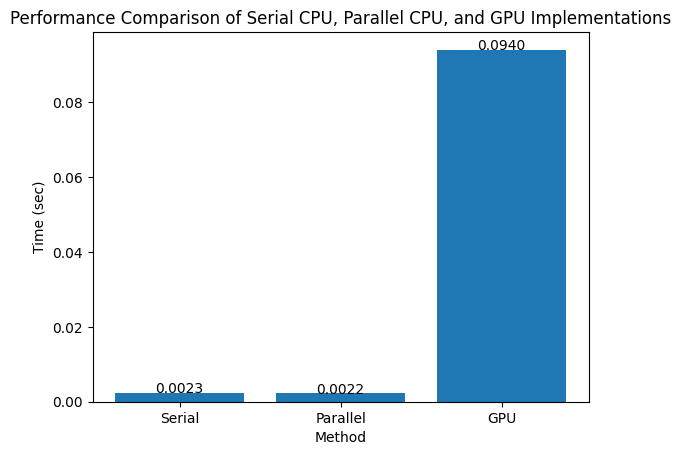

In [17]:
import matplotlib.pyplot as plt

# Read CPU times
with open("output.txt") as f:
    serial, parallel = map(float, f.read().split())

# ✅ Use your actual GPU time
gpu_time = 0.0940

methods = ['Serial', 'Parallel', 'GPU']
times = [serial, parallel, gpu_time]

plt.figure()
plt.bar(methods, times)

# Add values on bars
for i, v in enumerate(times):
    plt.text(i, v, f"{v:.4f}", ha='center')

plt.title("Performance Comparison of Serial CPU, Parallel CPU, and GPU Implementations")
plt.ylabel("Time (sec)")
plt.xlabel("Method")

plt.savefig("performance comparison.png")
plt.show()